# Statistique bivariée
 
Analyse des relations entre deux variables

# CAS 3 : QUALI ↔ QUALI  
**Exemple : sexe ↔ retour_produit**

*Variables* : sexe, retour_produit   
*Indicateurs* : Table de contingence  
*Graphiques* : Count plot , heatmap  
*Objectif* : Examiner l'association entre deux catégories

In [5]:
# importation des biblios necessaires 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set(style="whitegrid")
except:
    sns = None
    
# chargement du jeu de données 
df = pd.read_csv("ecommerce_dataset.csv")
df.head()


,client_id,sexe,âge,revenu_mensuel,segment_age,revenu_cat,produit,canal_achat,montant_panier,panier_frequent,note_satisfaction,retour_produit,date_achat
0,1,Homme,50,3893.70,Mature,Moyen,Sport,Mobile,83.27,Non,2,Non,2023-05-28
1,2,Femme,39,2885.15,Adulte,Moyen,Électronique,Mobile,47.18,Oui,3,Non,2023-01-13
2,3,Homme,44,2369.53,Mature,Moyen,Sport,Mobile,72.28,Oui,4,Non,2023-03-13
3,4,Homme,38,3197.92,Adulte,Moyen,Électronique,Mobile,54.59,Non,3,Non,2023-05-07
4,5,Homme,20,3774.66,Jeune,Moyen,Sport,Mobile,75.30,Non,4,Non,2023-07-04


In [7]:
#tableau croisé (tableau de contingence) qui compte combien de fois chaque combinaison 
# "sexe" / "retour_produit" apparaît
table = pd.crosstab(df["sexe"], df["retour_produit"])
table

retour_produit,Non,Oui
sexe,,
Femme,6722,757
Homme,6718,803


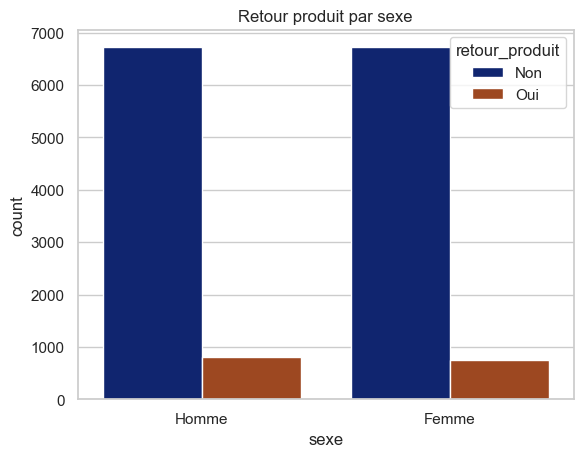

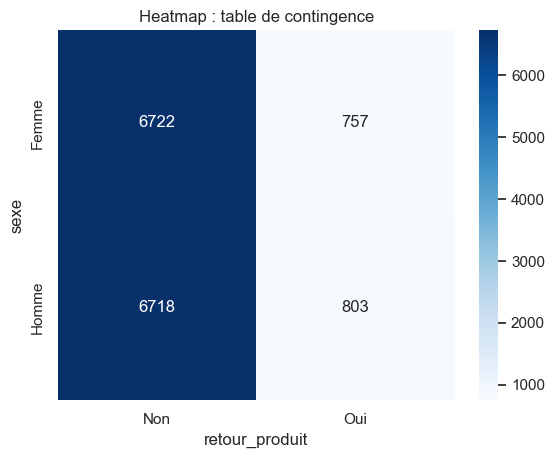

In [24]:
if sns:
    plt.figure()
# Dessine graphique en barres qui compte  le nombre de clients par "sexe"
# en séparant par couleur selon "retour_produit" (hue = couleur de séparation)
# -> permet de voir, pour chaque sexe, combien [n']ont [pas] retourné le produit
# palette = couleurs
    sns.countplot(x="sexe", hue="retour_produit", data=df , palette ="dark")
    plt.title("Retour produit par sexe")
    plt.show()
#nouvelle image pour le deuxième graph
    plt.figure()
    #heatmap a partir du tableau de contingence
    sns.heatmap(table, annot=True, fmt="d", cmap="Blues")
    plt.title("Heatmap : table de contingence")
    plt.show()

In [19]:
# Table de contingence brute
# Compte le nombre de clients pour chaque combinaison sexe / retour_produit
table = pd.crosstab(df["sexe"], df["retour_produit"])

# Table des proportions (chaque ligne fait 100%)
# Passe les effectifs en pourcentage , ligne par ligne
table_prop = table.div(table.sum(axis=1), axis=0) * 100

table_prop

retour_produit,Non,Oui
sexe,,
Femme,89.878326,10.121674
Homme,89.323228,10.676772


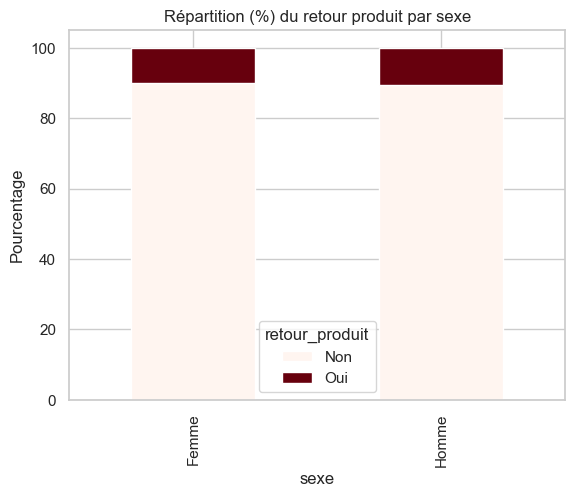

In [26]:
# Graphiques de barres empilées 
# -> stacked=True = les catégories sont empilées les unes sur les autres 
table_prop.plot(kind="bar", stacked=True, colormap="Reds")
plt.title("Répartition (%) du retour produit par sexe")
plt.ylabel("Pourcentage")
plt.show()

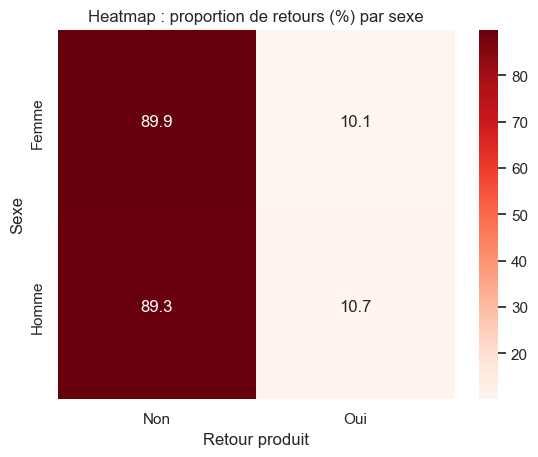

In [29]:
plt.figure
# heatmap à partir des pourcentages
# annot=True => affiche les chiffres directement dans chaque case
sns.heatmap(table_prop, annot=True, fmt=".1f", cmap="Reds")
plt.title("Heatmap : proportion de retours (%) par sexe")
plt.ylabel("Sexe")
plt.xlabel("Retour produit")
plt.show()

#  Récap

- **QUANTI ↔ QUANTI** : force et sens de la relation, covariance, corrélation, scatter plot  
- **QUALI ↔ QUANTI (2 modalities)** : moyenne par cat, comparer deux groupes, boxplot, violin plot,
- **QUALI ↔ QUANTI (3+ modalities)** : moyenne par grp, comparer plusieurs groupes, boxplot, barplot  
- **QUALI ↔ QUALI** : examiner l'association entre deux catégories, table de contingence, countplot, heatmap  
